In [138]:
using Oceananigans
using CairoMakie
using CairoMakie.Colors
using Statistics

include("../src-fig/figures/preinitial_conditions.jl")
include("../src-simulation/parameters.jl")
include("../src-simulation/base_state.jl")
include("../src-simulation/grid_faces.jl")

include("../src-fig/plotting.jl")
include("front.jl")

front_width (generic function with 1 method)

In [2]:
DFM = "../../scratch/turbulence-at-many-fronts/Strain-l8/DFM.jld2"
RI = "../../scratch/turbulence-at-many-fronts/Strain-l8/RI.jld2"
PV = "../../scratch/turbulence-at-many-fronts/Strain-l8/PV.jld2"
TKE = "../../scratch/turbulence-at-many-fronts/Strain-l8/TKE.jld2"

iterations, times = iterations_times(DFM)
sp = simulation_parameters(DFM)
xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(DFM)
inds = center_indices(DFM)
grid = jldopen(get_grid, DFM)

1024×128×64 RectilinearGrid{Float64, Bounded, Periodic, Bounded} on CPU with 5×5×5 halo
├── Bounded  x ∈ [-16000.0, 16000.0] variably spaced with min(Δx)=5.20833, max(Δx)=315.273
├── Periodic y ∈ [-333.333, 333.333) regularly spaced with Δy=5.20833
└── Bounded  z ∈ [-150.0, 0.0]       regularly spaced with Δz=2.34375

In [ ]:
db = -sp.Δb / 6
BT = cumulative_avg_b(DFM)

b_center = avg_buoyancy(DFM, -95, -5)
b_surface = avg_buoyancy(DFM, -10, -5)
b_maximum = timeseries_of(DFM, "b_dfm", iterations) do field
    maximum(field; dims = 2)[:, 1]
end
η, η_k = mixed_layer_height(DFM, b_surface, db);

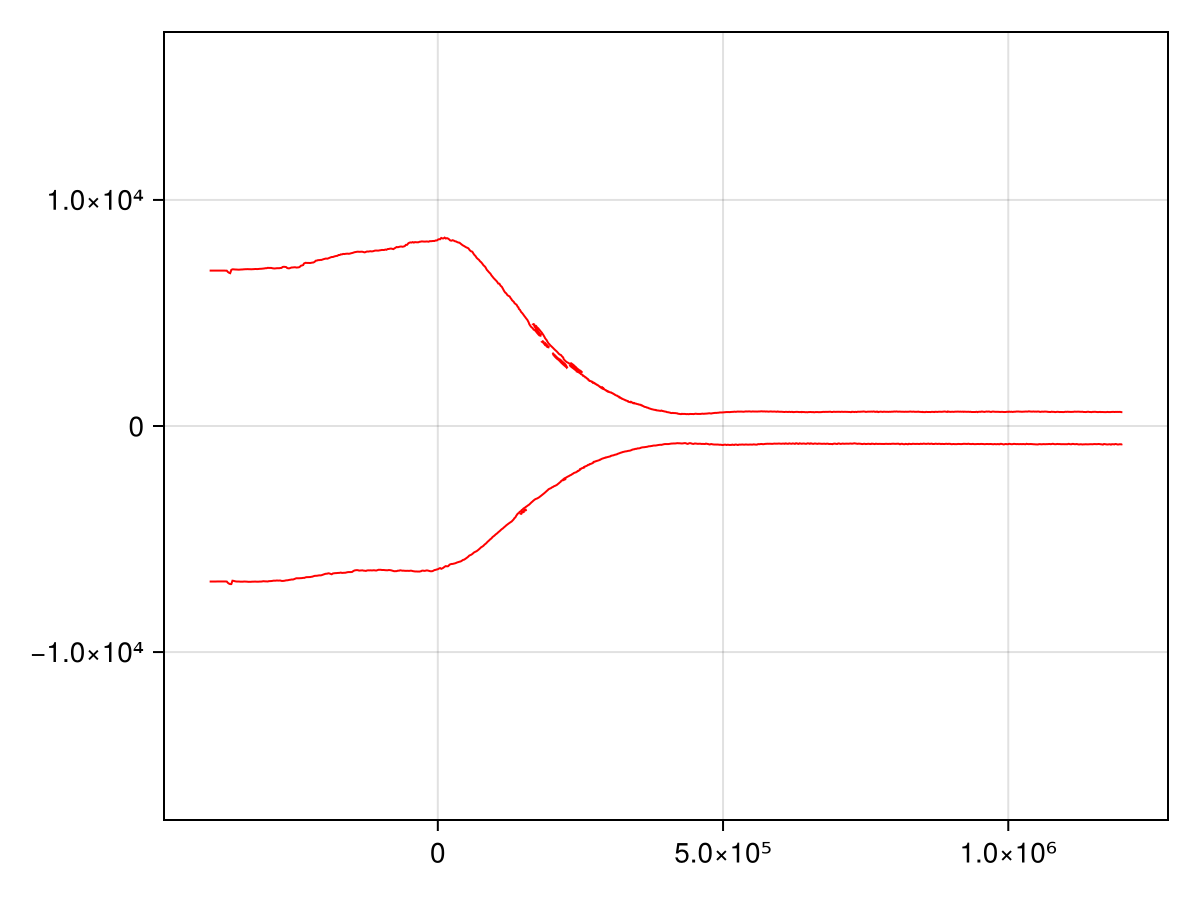

In [144]:
bl = -sp.Δb / 3
br = sp.Δb / 3
levels = [bl, br]
contour(times, xsᶜ, b_center .- mean(b_center; dims=2); levels, color=:red)
#contour(times, xsᶜ, b_maximum .- mean(b_maximum; dims=2); levels, color=:red)

# Averaging over the front

There are multiple domains of interest. By inspection, we can see that in the final state the front is well-mixed only at the edges. We need to create a kernel that averages over the front somehow.

$$
b_\text{max}(x, t) = \max_z b(x, z, t)
$$

In [ ]:
n = 701

bl = mean(b_center[n, :]) - sp.Δb / 3
br = mean(b_center[n, :]) + sp.Δb / 3

fig = Figure(; fontsize=18, size=(1000, 400))
ax = Axis(fig[1, 1];
    xlabel = L"x / \text{km}",
    ylabel = L"z / \text{m}",
    limits = (-sp.Lh / 2000, sp.Lh / 2000, -sp.Lz, 0)
)

b = get_field(DFM, "b_dfm", iterations[n])
#b_maximum = maximum(b; dims=2)[:]

# Vertical lines at a larger width
xl, xr = let 
    bl = -sp.Δb / 3
    br = sp.Δb / 3
    xl = interpolate(bl, b_maximum[n, :] .- mean(b_maximum[n, :]), xsᶜ)
    xr = interpolate(br, b_maximum[n, :] .- mean(b_maximum[n, :]), xsᶜ)
    xl, xr
end

levels = mean(b_center[n, :]) .+ (-sp.Δb):(sp.Δb / 6):(sp.Δb)
colormap = reverse(to_colormap(:deep))

contourf!(ax, xsᶜ ./ 1000, zsᶜ, b; 
    colormap,
    levels
)

contour!(ax, xsᶜ ./ 1000, zsᶜ, b; 
    color = :red,
    levels = [bl],
    linestyle = :dash
)
contour!(ax, xsᶜ ./ 1000, zsᶜ, b; 
    color = :red,
    levels = [br],
    linestyle = :dash
)
lines!(ax, xsᶜ ./ 1000, η[n, :];
    color = :blue,
    linestyle = :dash
)
lines!(ax, [-sp.Lx, sp.Lx] ./ 2000, [-0.95sp.H, -0.95sp.H];
    color = :blue
)
lines!(ax, [-sp.Lx, sp.Lx] ./ 2000, [-0.05sp.H, -0.05sp.H];
    color = :blue
)

lines!(ax, [xl, xl] ./ 1000, [-sp.H, 0];
    color = :red
)
lines!(ax, [xr, xr] ./ 1000, [-sp.H, 0];
    color = :red
)

fig

In [129]:
function front_average(field, b, bl, br, Δxᶜ, zsᶜ, sp; η_k=[-sp.H for i in 1:sp.Nx])
    inds = front_indices(b, η_k, bl, br, zsᶜ, sp)
    return sum((field .* Δxᶜ)[inds]) / sum(inds .* Δxᶜ)
end

function front_indices(b, bl, br, zsᶜ, sp; η_k=[-sp.H for i in 1:sp.Nx])
    buoyancy = bl .<= b .<= br
    height = -0.95sp.H .<= zsᶜ .<= -0.05sp.H
    for i in axes(buoyancy, 1), k in axes(buoyancy, 2)
        buoyancy[i, k] = buoyancy[i, k] && height[k] && k >= η_k[i]
    end
    return buoyancy
end

front_indices (generic function with 3 methods)

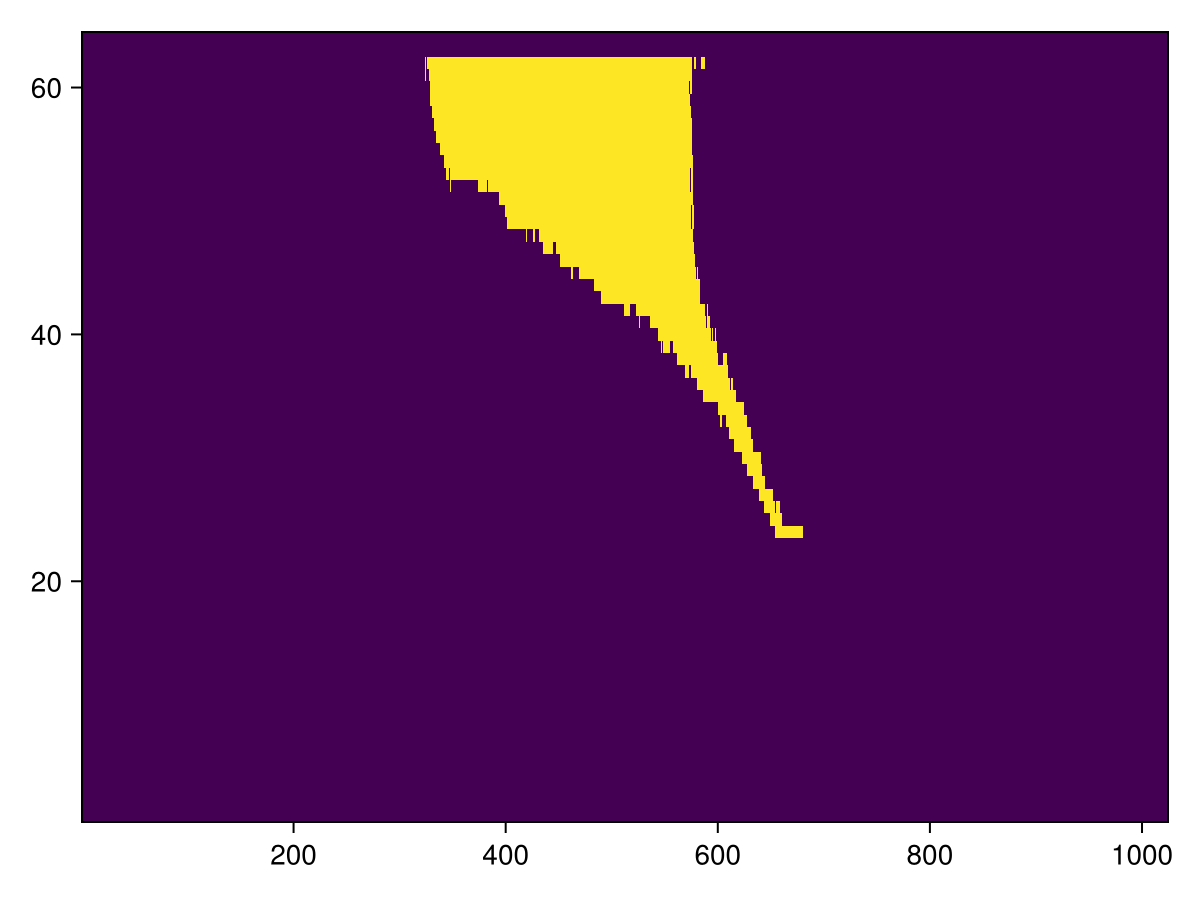

In [122]:
n = 601
b = get_field(DFM, "b_dfm", iterations[n])

bl = - sp.Δb / 3
br = sp.Δb / 3

inds = front_indices(b .- mean(b_center[n, :]), bl, br, zsᶜ, sp; η_k=η_k[n, :])
heatmap(inds)

In [133]:
foldernames = [
    "../../scratch/turbulence-at-many-fronts/Strain-l2",
    "../../scratch/turbulence-at-many-fronts/Strain-l4",
    "../../scratch/turbulence-at-many-fronts/Strain-l6",
    "../../scratch/turbulence-at-many-fronts/Strain-l8",
]

RIs = map(foldernames) do foldername 
    joinpath(foldername, "RI.jld2")
end

Ri_balanced_mld = map(foldernames) do foldername
    println(foldername)
    
    RI = joinpath(foldername, "RI.jld2")
    DFM = joinpath(foldername, "DFM.jld2")
    
    iterations, times = iterations_times(DFM)
    sp = simulation_parameters(DFM)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(DFM)
    
    b_surface = avg_buoyancy(DFM, -10, -5)
    b_center = avg_buoyancy(DFM, -95, -5)
    bl = -sp.Δb / 3
    br = sp.Δb / 3
    db = -sp.Δb / 6
    η, η_k = mixed_layer_height(DFM, b_surface, db)

    Δxᶜ = reshape(diff(xsᶠ), sp.Nx, 1)
    Ri_avg = zeros(length(times))
    for n in axes(iterations, 1)
        print("$n\r")
        N² = get_field(RI, "N²", iterations[n])
        N² = (N²[:, 1:end-1] .+ N²[:, 2:end]) ./ 2
        
        M² = get_field(RI, "M²", iterations[n])
        M² = (M²[1:end-1, :] .+ M²[2:end, :]) ./ 2

        b = get_field(DFM, "b_dfm", iterations[n])
        
        Ri_avg[n] = sp.f^2 * front_average(N², b .- mean(b_center[n, :]), bl, br, Δxᶜ, zsᶜ, sp; η_k=η_k[n, :]) / front_average(M², b .- mean(b_center[n, :]), bl, br, Δxᶜ, zsᶜ, sp; η_k=η_k[n, :])^2
    end
    println()

    Ri_avg
end


../../scratch/turbulence-at-many-fronts/Strain-l2
801
../../scratch/turbulence-at-many-fronts/Strain-l4
801
../../scratch/turbulence-at-many-fronts/Strain-l6
801
../../scratch/turbulence-at-many-fronts/Strain-l8
801


4-element Vector{Vector{Float64}}:
 [5.151993698529145, 5.151834092474197, 5.151286146844917, 5.150524079462595, 5.148670183778126, 5.147267980051213, 5.165515465983165, 5.164522040857612, 5.1631216032119225, 5.1618095670824555  …  0.724050218124502, 0.7376973438544312, 0.7368291170777814, 0.7199802294688158, 0.7064623173610776, 0.709087404017653, 0.7012974668218825, 0.712318476760725, 0.7180283377033021, 0.7044094961700352]
 [20.62871385824794, 20.628556882545702, 20.628093509052604, 20.62734059625923, 20.626322974177917, 20.625076807005794, 20.62364400339282, 20.62207576788545, 20.620430195048698, 20.61746395359543  …  0.7051400740061813, 0.7035991134088905, 0.699702816522299, 0.7114343690450032, 0.717164287997583, 0.7286937814282889, 0.7054770807079086, 0.6976723205509936, 0.7103789504034088, 0.7279619648262469]
 [46.31766034320226, 46.317505704796325, 46.317048079955946, 46.31630507872757, 46.315304322068805, 46.314077497385284, 46.31266139468776, 46.311108082832, 46.30946951465535

In [134]:
Ri_balanced = map(foldernames) do foldername
    println(foldername)
    
    RI = joinpath(foldername, "RI.jld2")
    DFM = joinpath(foldername, "DFM.jld2")
    
    iterations, times = iterations_times(DFM)
    sp = simulation_parameters(DFM)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(DFM)
    
    b_surface = avg_buoyancy(DFM, -10, -5)
    b_center = avg_buoyancy(DFM, -95, -5)
    bl = -sp.Δb / 3
    br = sp.Δb / 3
    db = -sp.Δb / 6
    η, η_k = mixed_layer_height(DFM, b_surface, db)

    Δxᶜ = reshape(diff(xsᶠ), sp.Nx, 1)
    Ri_avg = zeros(length(times))
    for n in axes(iterations, 1)
        print("$n\r")
        N² = get_field(RI, "N²", iterations[n])
        N² = (N²[:, 1:end-1] .+ N²[:, 2:end]) ./ 2
        
        M² = get_field(RI, "M²", iterations[n])
        M² = (M²[1:end-1, :] .+ M²[2:end, :]) ./ 2

        b = get_field(DFM, "b_dfm", iterations[n])
        
        Ri_avg[n] = sp.f^2 * front_average(N², b .- mean(b_center[n, :]), bl, br, Δxᶜ, zsᶜ, sp) / front_average(M², b .- mean(b_center[n, :]), bl, br, Δxᶜ, zsᶜ, sp)^2
    end
    println()

    Ri_avg
end

../../scratch/turbulence-at-many-fronts/Strain-l2
801
../../scratch/turbulence-at-many-fronts/Strain-l4
801
../../scratch/turbulence-at-many-fronts/Strain-l6
801
../../scratch/turbulence-at-many-fronts/Strain-l8
801


4-element Vector{Vector{Float64}}:
 [25.093209170590228, 25.091404210539455, 25.089284468503944, 25.081062776789953, 25.07132646927529, 25.059879965728925, 24.985948559171472, 24.975055762121166, 24.96455144180107, 24.955205866961347  …  0.9667512736377059, 0.9644859374392193, 0.9669965862780444, 0.9580117994247054, 0.9476757036247038, 0.9508241282457518, 0.9446799657787525, 0.9492875939820573, 0.9530216778269346, 0.9522050978705531]
 [63.07042840527001, 63.06881441841606, 63.064125858186216, 63.05673911383119, 63.047148343692804, 63.03589431940723, 63.02997209417119, 63.01713723323475, 63.004361159487516, 62.994400091837655  …  0.9621824743657649, 0.9581897286293536, 0.9609265083666472, 0.9607825431289622, 0.9610103059002786, 0.9648149752296469, 0.9601345402660235, 0.9597029609486387, 0.9625856915851817, 0.9654590032306224]
 [115.89775738300504, 115.89659166517002, 115.89254938695682, 115.89554607900166, 115.88656758171166, 115.87562131671716, 115.86333996892995, 115.85040283463916, 1

In [135]:
Ri = map(foldernames) do foldername
    println(foldername)
    
    RI = joinpath(foldername, "RI.jld2")
    DFM = joinpath(foldername, "DFM.jld2")
    
    iterations, times = iterations_times(DFM)
    sp = simulation_parameters(DFM)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(DFM)
    
    b_surface = avg_buoyancy(DFM, -10, -5)
    b_center = avg_buoyancy(DFM, -95, -5)
    bl = -sp.Δb / 3
    br = sp.Δb / 3
    db = -sp.Δb / 6
    η, η_k = mixed_layer_height(DFM, b_surface, db)

    Δxᶜ = reshape(diff(xsᶠ), sp.Nx, 1)
    Ri_avg = zeros(length(times))
    for n in axes(iterations, 1)
        print("$n\r")
        N² = get_field(RI, "N²", iterations[n])
        N² = (N²[:, 1:end-1] .+ N²[:, 2:end]) ./ 2
        
        Sx = get_field(RI, "Sx", iterations[n])
        Sx = (Sx[:, 1:end-1] .+ Sx[:, 2:end]) ./ 2

        Sy = get_field(RI, "Sx", iterations[n])
        Sy = (Sy[:, 1:end-1] .+ Sy[:, 2:end]) ./ 2

        S² = Sx.^2 .+ Sy.^2
        b = get_field(DFM, "b_dfm", iterations[n])
        
        Ri_avg[n] = front_average(N², b .- mean(b_center[n, :]), bl, br, Δxᶜ, zsᶜ, sp) / front_average(S², b .- mean(b_center[n, :]), bl, br, Δxᶜ, zsᶜ, sp)
    end
    println()

    Ri_avg
end

../../scratch/turbulence-at-many-fronts/Strain-l2
801
../../scratch/turbulence-at-many-fronts/Strain-l4
801
../../scratch/turbulence-at-many-fronts/Strain-l6
801
../../scratch/turbulence-at-many-fronts/Strain-l8
801


4-element Vector{Vector{Float64}}:
 [4.917245650793946e25, 1.9089231218647133e6, 496116.2595900531, 235780.20144849792, 145830.80577531847, 105681.33205044597, 85485.91356265891, 75967.36652350207, 73129.23120797914, 75959.30885852182  …  1.5384262385024219, 1.5670917046151505, 1.560048969046313, 1.5381981335762498, 1.535435852226831, 1.5610514387373957, 1.5500674852387377, 1.5526893396329615, 1.5487564972779913, 1.5360014352242133]
 [3.5724403379165553e25, 5.088051303769446e6, 1.3241079490134278e6, 629649.6595304991, 389937.31312785245, 283210.34087809024, 230525.46128312591, 205946.2269347203, 199804.8224087917, 209985.22879027858  …  1.2965574667910507, 1.2856985683079514, 1.2937472239688124, 1.280686536806195, 1.2966561584537266, 1.2961020565397745, 1.3035976903899342, 1.2840414461238268, 1.2834730090800972, 1.3333107528992503]
 [2.858814678459649e25, 9.541241648525802e6, 2.483476324429522e6, 1.180774071213786e6, 731334.1201185533, 531228.102727591, 432677.6850196751, 386646.144874

In [136]:
Ri_mld = map(foldernames) do foldername
    println(foldername)
    
    RI = joinpath(foldername, "RI.jld2")
    DFM = joinpath(foldername, "DFM.jld2")
    
    iterations, times = iterations_times(DFM)
    sp = simulation_parameters(DFM)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(DFM)
    
    b_surface = avg_buoyancy(DFM, -10, -5)
    b_center = avg_buoyancy(DFM, -95, -5)
    bl = -sp.Δb / 3
    br = sp.Δb / 3
    db = -sp.Δb / 6
    η, η_k = mixed_layer_height(DFM, b_surface, db)

    Δxᶜ = reshape(diff(xsᶠ), sp.Nx, 1)
    Ri_avg = zeros(length(times))
    for n in axes(iterations, 1)
        print("$n\r")
        N² = get_field(RI, "N²", iterations[n])
        N² = (N²[:, 1:end-1] .+ N²[:, 2:end]) ./ 2
        
        Sx = get_field(RI, "Sx", iterations[n])
        Sx = (Sx[:, 1:end-1] .+ Sx[:, 2:end]) ./ 2

        Sy = get_field(RI, "Sx", iterations[n])
        Sy = (Sy[:, 1:end-1] .+ Sy[:, 2:end]) ./ 2

        S² = Sx.^2 .+ Sy.^2
        b = get_field(DFM, "b_dfm", iterations[n])
        
        Ri_avg[n] = front_average(N², b .- mean(b_center[n, :]), bl, br, Δxᶜ, zsᶜ, sp; η_k=η_k[n, :]) / front_average(S², b .- mean(b_center[n, :]), bl, br, Δxᶜ, zsᶜ, sp; η_k=η_k[n, :])
    end
    println()

    Ri_avg
end

../../scratch/turbulence-at-many-fronts/Strain-l2
801
../../scratch/turbulence-at-many-fronts/Strain-l4
801
../../scratch/turbulence-at-many-fronts/Strain-l6
801
../../scratch/turbulence-at-many-fronts/Strain-l8
801


4-element Vector{Vector{Float64}}:
 [1.288587680924894e25, 779824.6819586406, 202080.7993536704, 95433.75741079918, 58543.96658398841, 42017.0731293277, 33861.682904048386, 29717.07923863108, 28205.954419219976, 28814.73154428271  …  0.8856530220130031, 0.9323146342751507, 0.9450660531897511, 0.9381025765112161, 0.9582868099320329, 0.972682929858292, 0.9726853147905524, 0.9839215540850197, 0.994021659691382, 0.9844358989163614]
 [1.269992925961477e25, 3.1297887351349383e6, 813662.0194771087, 386276.59214702935, 238673.33488120162, 172846.3497622404, 140258.94794560812, 124771.09100247255, 120431.77479556006, 125789.69862931692  …  0.904109479538937, 0.9056516136369324, 0.8902028289809567, 0.8757219656303722, 0.88290389427251, 0.8633239308696805, 0.8635208094762344, 0.851264209923481, 0.8338650645078383, 0.8506316830465245]
 [1.1611033251749462e25, 7.020874676401479e6, 1.8263955380411912e6, 867968.4874366388, 537089.5883954512, 389701.0672562637, 316986.2940377346, 282817.75030121254, 2

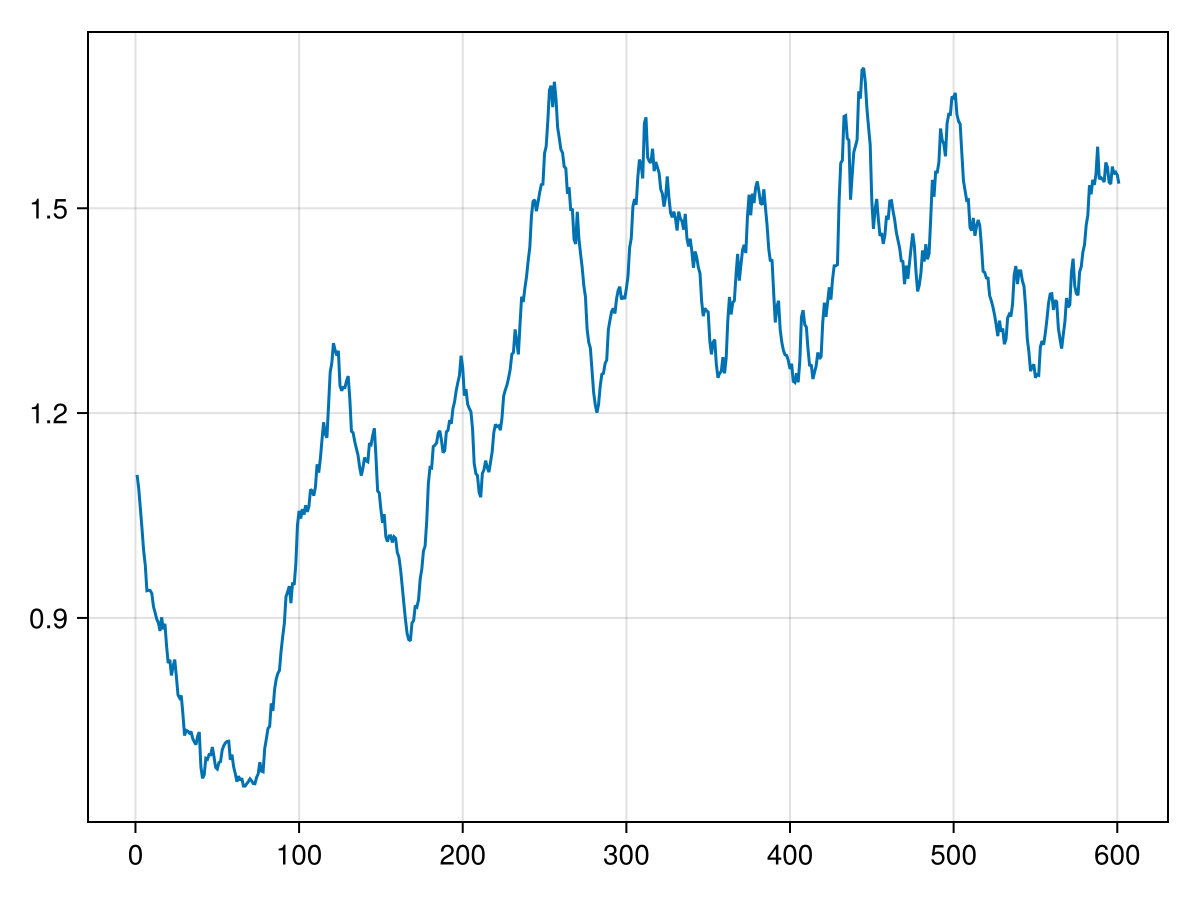

In [141]:
lines(Ri[1][201:end])